# 02: Lifetime distributions of FD001 and FD003

Study level 1 (reliability statistics). Notebook 01 showed that FD001 lifetimes are right-skewed and that a clock alone is off by about 46 cycles on average. This notebook puts a distribution on those lifetimes and asks what the fleet-level view buys us before any sensor is used.

Questions, each answered by one section and collected in the Decisions cell at the end:

1. Which family describes the lifetimes, and does it matter where "zero" is placed (two- vs three-parameter Weibull)?
2. Is the hazard increasing, i.e. is this a pure wear-out population, and where does it start to rise?
3. What RUL error does a fleet-only "clock" model reach on the FD001 test set? This is the baseline every sensor model must beat.
4. How does a second fault mode (FD003: HPC + fan degradation) change shape, tail and fit quality?
5. How should censored engines (the test files, or a fleet in operation) enter a survival estimate?

Cells marked **Your reading** are the exercise: write the interpretation in your own words before moving on. The DIMAP entries in `docs/learning/01-reliability-statistics.md` point back to each section.

## 1. Load lifetimes

A lifetime is the last cycle of a training engine. For test engines we only observe a truncated prefix; the true remaining life at the cut is in `RUL_FD00x.txt`. Both are loaded here because sections 5 and 7 need them.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from turbofan_rul.data_loading import load_subset, load_test_rul
from turbofan_rul.evaluation import phm08_score, rmse


def lifetimes(subset: str) -> pd.Series:
    # Last observed cycle per training engine = cycles until failure.
    df = load_subset(subset, split="train")
    return df.groupby("unit")["cycle"].max().rename("lifetime")


def test_ages(subset: str) -> pd.DataFrame:
    # Test engines: observed cycles at the cut (age) and true remaining life at that point.
    df = load_subset(subset, split="test")
    age = df.groupby("unit")["cycle"].max().rename("age")
    return pd.concat([age, load_test_rul(subset)], axis=1)


life = lifetimes("FD001")
test = test_ages("FD001")

assert len(life) == 100 and len(test) == 100
assert (test["rul"] > 0).all(), "every test engine is cut before failure"
life.describe().round(1)

count    100.0
mean     206.3
std       46.3
min      128.0
25%      177.0
50%      199.0
75%      229.2
max      362.0
Name: lifetime, dtype: float64

## 2. Empirical survival and the summaries that matter

The histogram is in notebook 01. Here we look at the same 100 numbers as a survival curve S(t) = fraction of engines still running at age t, and at its log. Under an exponential (no ageing) model, log S(t) is a straight line through the origin; any downward bend means the hazard increases with age.

Three summaries are compared: the mean (MTTF), the median, and the B10 life (age by which 10% of the fleet has failed).

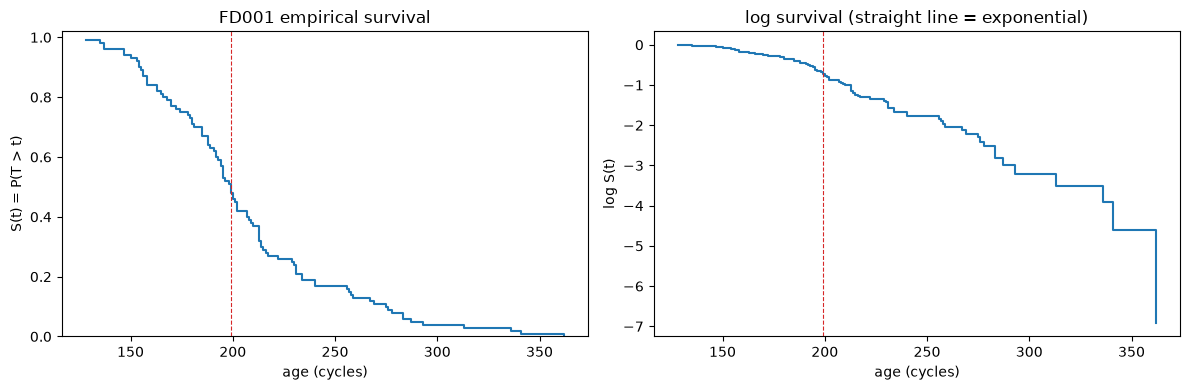

MTTF (mean)         206.3
median              199.0
B10 (10% failed)    154.9
B1 (1% failed)      134.9
min                 128.0
max                 362.0
dtype: float64

In [2]:
def empirical_survival(t: pd.Series) -> pd.Series:
    # Step function: S(t_i) = fraction of lifetimes strictly greater than t_i, at each observed t_i.
    t_sorted = np.sort(t.values)
    s = 1 - np.arange(1, len(t_sorted) + 1) / len(t_sorted)
    return pd.Series(s, index=t_sorted, name="S")


S_emp = empirical_survival(life)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].step(S_emp.index, S_emp.values, where="post")
axes[0].set(xlabel="age (cycles)", ylabel="S(t) = P(T > t)", title="FD001 empirical survival", ylim=(0, 1.02))
axes[1].step(S_emp.index, np.log(S_emp.values.clip(min=1e-3)), where="post")
axes[1].set(xlabel="age (cycles)", ylabel="log S(t)", title="log survival (straight line = exponential)")
for ax in axes:
    ax.axvline(life.median(), color="C3", ls="--", lw=0.8)
plt.tight_layout()
plt.show()

summary = pd.Series(
    {
        "MTTF (mean)": life.mean(),
        "median": life.median(),
        "B10 (10% failed)": life.quantile(0.10),
        "B1 (1% failed)": life.quantile(0.01),
        "min": life.min(),
        "max": life.max(),
    }
).round(1)
summary

**Your reading.** Is log S(t) straight? Where does it start to bend? If maintenance were scheduled at the MTTF, what fraction of the fleet would have failed already? Which of the three summaries would you give to someone planning inspections?

## 3. Fitting candidate distributions

Four candidates, all fitted by maximum likelihood with `scipy.stats`:

- Exponential: constant hazard, the "no ageing" null model.
- Weibull, two parameters (location fixed at 0): shape k and scale λ.
- Weibull, three parameters: adds a location (threshold) below which no failure can occur.
- Lognormal (location fixed at 0): the usual competitor for right-skewed lifetimes.

Comparison on three levels: log-likelihood and AIC (penalises the extra parameter), the Kolmogorov–Smirnov statistic, and a table of fitted vs empirical quantiles that shows *where* a model is wrong. Note on KS: `kstest` assumes the parameters were known beforehand. They were estimated from the same sample, so the p-values are optimistic; use them to rank models, not to certify one.

In [3]:
def fit_candidates(t: pd.Series) -> dict[str, stats.rv_continuous]:
    # Returns frozen distributions, so each one carries its own parameters.
    x = t.values.astype(float)
    return {
        "exponential": stats.expon(*stats.expon.fit(x, floc=0)),
        "weibull2": stats.weibull_min(*stats.weibull_min.fit(x, floc=0)),
        "weibull3": stats.weibull_min(*stats.weibull_min.fit(x)),
        "lognormal": stats.lognorm(*stats.lognorm.fit(x, floc=0)),
    }


def fit_table(t: pd.Series, fits: dict) -> pd.DataFrame:
    x = t.values.astype(float)
    rows = {}
    for name, d in fits.items():
        n_free = {"exponential": 1, "weibull2": 2, "weibull3": 3, "lognormal": 2}[name]
        loglik = d.logpdf(x).sum()
        ks = stats.kstest(x, d.cdf)
        rows[name] = {
            "params": ", ".join(f"{p:.2f}" for p in d.args),
            "loglik": loglik,
            "AIC": 2 * n_free - 2 * loglik,
            "KS stat": ks.statistic,
            "KS p (optimistic)": ks.pvalue,
            "mean": d.mean(),
            "median": d.median(),
            "B10": d.ppf(0.10),
        }
    return pd.DataFrame(rows).T.astype({c: float for c in ["loglik", "AIC", "KS stat", "KS p (optimistic)", "mean", "median", "B10"]})


fits = fit_candidates(life)
fit_table(life, fits).round(3)

,params,loglik,AIC,KS stat,KS p (optimistic),mean,median,B10
exponential,"0.00, 206.31",-632.938,1267.876,0.470,0.000,206.310,143.003,21.737
weibull2,"4.41, 0.00, 225.03",-530.749,1065.498,0.157,0.013,205.109,207.075,135.068
weibull3,"1.83, 125.19, 91.29",-516.516,1039.032,0.094,0.319,206.316,199.915,151.883
lognormal,"0.21, 0.00, 201.59",-517.456,1038.912,0.094,0.317,206.178,201.592,153.609


`params` are printed in scipy's order: shape(s), loc, scale. For `weibull2` that is (k, 0, λ); for `weibull3` (k, threshold, λ); for `lognormal` (σ of log T, 0, exp(μ)); for `exponential` (0, λ).

In [4]:
qs = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
quantiles = pd.DataFrame({"empirical": life.quantile(qs).values}, index=qs)
for name, d in fits.items():
    quantiles[name] = d.ppf(qs)
quantiles.round(0).astype(int)

,empirical,exponential,weibull2,weibull3,lognormal
0.01,135,2,79,133,123
0.05,147,11,115,143,142
0.10,155,22,135,152,154
0.25,177,59,170,171,175
0.50,199,143,207,200,202
0.75,229,286,242,234,233
0.90,275,475,272,269,265
0.95,287,618,289,291,286
0.99,341,950,318,336,330


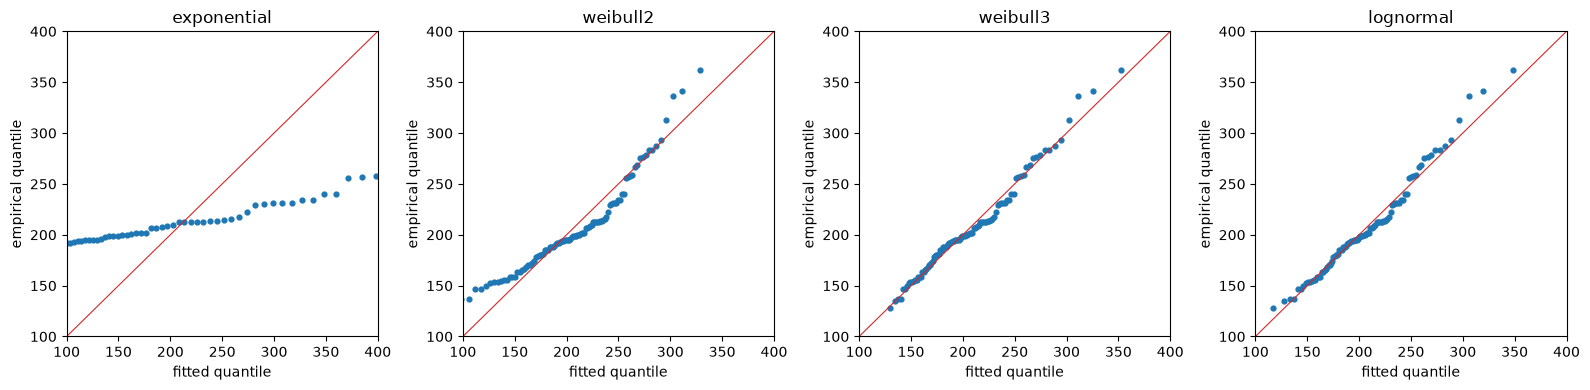

In [5]:
# Probability plots: empirical quantiles against fitted quantiles. A good model follows the diagonal.
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
probs = (np.arange(1, len(life) + 1) - 0.5) / len(life)
x_emp = np.sort(life.values)
for ax, (name, d) in zip(axes, fits.items(), strict=True):
    ax.scatter(d.ppf(probs), x_emp, s=12)
    lim = (100, 400)
    ax.plot(lim, lim, color="C3", lw=0.8)
    ax.set(title=name, xlabel="fitted quantile", ylabel="empirical quantile", xlim=lim, ylim=lim)
plt.tight_layout()
plt.show()

**Your reading.** Which model fails, and in which tail? Compare the 5% quantile of `weibull2` with the earliest observed failure. Why does freeing the location change the shape parameter so much (from about 4.4 to about 1.8) if both are "Weibull"? Can `weibull3` and `lognormal` be told apart on 100 lifetimes? Which one would you carry forward, and on what grounds if the statistics do not decide?

## 4. Survival, hazard and conditional survival

The hazard h(t) is the failure rate among the engines that have reached age t. Its shape is what distinguishes infant mortality (decreasing), random failures (flat) and wear-out (increasing). The fitted models are overlaid on the empirical step curve; the empirical hazard itself is too noisy with 100 lifetimes, so only fitted hazards are drawn.

The last table is the quantity a maintenance planner actually needs: given an engine has reached age t, what is the probability it survives s more cycles, S(t + s) / S(t).

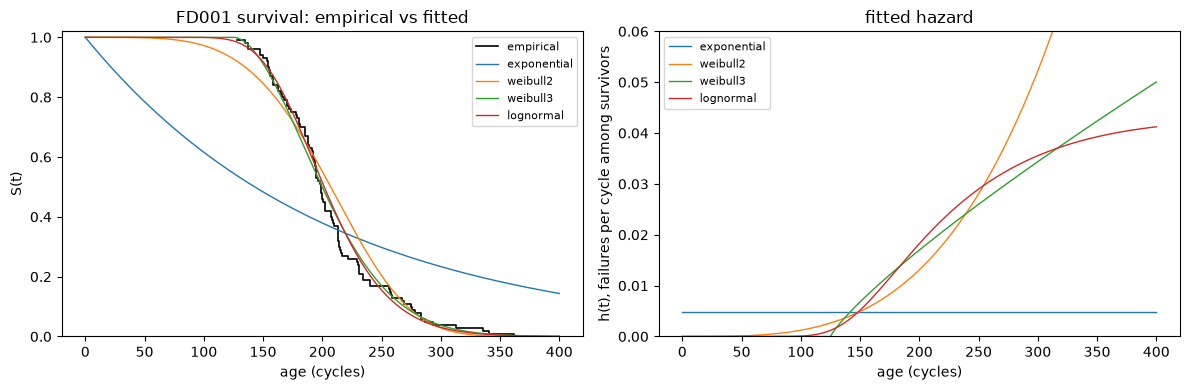

In [6]:
t_grid = np.linspace(0, 400, 401)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].step(S_emp.index, S_emp.values, where="post", color="k", lw=1.2, label="empirical")
for name in ["exponential", "weibull2", "weibull3", "lognormal"]:
    d = fits[name]
    axes[0].plot(t_grid, d.sf(t_grid), lw=1, label=name)
    # h(t) = f(t) / S(t); mask where S is ~0 to avoid blowing up.
    S = d.sf(t_grid)
    h = np.where(S > 1e-4, d.pdf(t_grid) / np.maximum(S, 1e-12), np.nan)
    axes[1].plot(t_grid, h, lw=1, label=name)
axes[0].set(xlabel="age (cycles)", ylabel="S(t)", title="FD001 survival: empirical vs fitted", ylim=(0, 1.02))
axes[0].legend(fontsize=8)
axes[1].set(xlabel="age (cycles)", ylabel="h(t), failures per cycle among survivors", title="fitted hazard", ylim=(0, 0.06))
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
def conditional_survival(d, ages, horizon):
    # P(T > t + horizon | T > t) for each age t.
    ages = np.asarray(ages, dtype=float)
    return d.sf(ages + horizon) / d.sf(ages)


ages = [50, 100, 150, 200, 250, 300]
cond = pd.DataFrame(index=pd.Index(ages, name="age t"))
for name in ["weibull2", "weibull3", "lognormal"]:
    cond[f"S(t) {name}"] = fits[name].sf(ages)
    cond[f"P(50 more | t) {name}"] = conditional_survival(fits[name], ages, 50)
cond.round(3)

,S(t) weibull2,P(50 more | t) weibull2,S(t) weibull3,P(50 more | t) weibull3,S(t) lognormal,P(50 more | t) lognormal
age t,,,,,,
50,0.999,0.974,1.000,1.000,1.000,1.000
100,0.972,0.870,1.000,0.912,1.000,0.919
150,0.846,0.652,0.912,0.547,0.918,0.561
200,0.552,0.369,0.499,0.340,0.515,0.301
250,0.204,0.140,0.170,0.221,0.155,0.196
300,0.029,0.032,0.038,0.147,0.030,0.153


**Your reading.** Is there any region where the hazard is flat or decreasing? At what age does it become non-negligible, and how does that compare with the 100 to 140 cycles-before-failure band from notebook 01? Read the conditional survival column: why is the probability of surviving 50 more cycles so different at age 100 and at age 200 if both engines are "healthy" by the sensors?

## 5. The clock model: a fleet-only RUL baseline

If the only thing we know about an engine is its age, the best RUL prediction comes from the conditional distribution of T given T > age. Two natural point predictions:

- Conditional median residual life: the s such that S(age + s) / S(age) = 0.5.
- Naive: MTTF − age, clipped at zero. This ignores that the engine has survived to `age`.

Both are evaluated on the 100 FD001 test engines, each at its cut age, with the true RUL from `RUL_FD001.txt`. Two metrics: RMSE (symmetric) and the PHM08 score (asymmetric, late predictions cost more). The scores from this cell are the baseline for notebooks 03 onward.

In [8]:
def median_residual_life(d, ages):
    # Solve S(age + s) = 0.5 * S(age) for s, using the inverse survival function.
    ages = np.asarray(ages, dtype=float)
    return d.isf(0.5 * d.sf(ages)) - ages


preds = pd.DataFrame(index=test.index)
preds["naive: MTTF - age"] = (life.mean() - test["age"]).clip(lower=0)
for name in ["weibull2", "weibull3", "lognormal"]:
    preds[f"cond. median {name}"] = median_residual_life(fits[name], test["age"])

baseline = pd.DataFrame(
    {
        "RMSE": {c: rmse(test["rul"], preds[c]) for c in preds},
        "PHM08 score": {c: phm08_score(test["rul"], preds[c]) for c in preds},
        "mean error (pred - true)": {c: (preds[c] - test["rul"]).mean() for c in preds},
    }
).round(1)
baseline

,RMSE,PHM08 score,mean error (pred - true)
naive: MTTF - age,40.2,25527.8,1.9
cond. median weibull2,38.0,10765.3,12.3
cond. median weibull3,35.9,6819.6,3.4
cond. median lognormal,36.4,7970.6,4.0


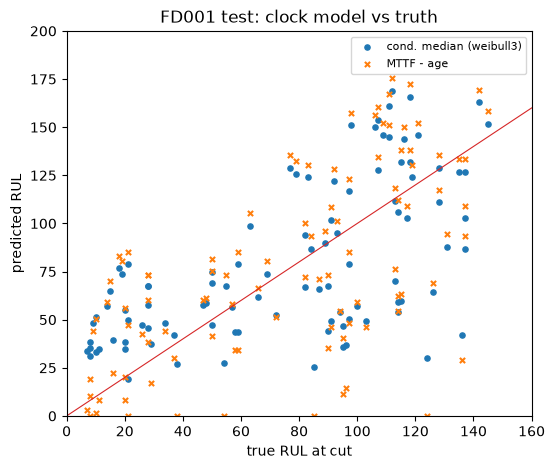

In [9]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(test["rul"], preds["cond. median weibull3"], s=14, label="cond. median (weibull3)")
ax.scatter(test["rul"], preds["naive: MTTF - age"], s=14, marker="x", label="MTTF - age")
lim = (0, 160)
ax.plot(lim, lim, color="C3", lw=0.8)
ax.set(xlabel="true RUL at cut", ylabel="predicted RUL", xlim=lim, ylim=(0, 200), title="FD001 test: clock model vs truth")
ax.legend(fontsize=8)
plt.show()

**Your reading.** Write down the RMSE and PHM08 score of the best clock model: this is the number to beat. Which direction does the clock model err in (early or late), and why does the PHM08 score punish that? Where in the scatter does it fail worst, and what would a sensor need to tell you to fix those engines? Compare the RMSE with the 46-cycle figure from notebook 01: are they measuring the same thing?

## 6. FD003: two fault modes

FD003 has the same single operating regime but two degradation modes (HPC and fan). If each engine suffers one of them, the fleet is a mixture of two lifetime populations, and a single Weibull should fit worse. Same pipeline, then the two subsets side by side.

In [10]:
life3 = lifetimes("FD003")
fits3 = fit_candidates(life3)

comparison = pd.concat(
    {"FD001": fit_table(life, fits), "FD003": fit_table(life3, fits3)}, axis=0
)[["params", "AIC", "KS stat", "mean", "median", "B10"]].round(2)
comparison

params      AIC  KS stat    mean  median  \
FD001 exponential          0.00, 206.31  1267.88     0.47  206.31  143.00   
      weibull2       4.41, 0.00, 225.03  1065.50     0.16  205.11  207.08   
      weibull3      1.83, 125.19, 91.29  1039.03     0.09  206.32  199.92   
      lognormal      0.21, 0.00, 201.59  1038.91     0.09  206.18  201.59   
FD003 exponential          0.00, 247.20  1304.04     0.44  247.20  171.35   
      weibull2       2.93, 0.00, 276.82  1177.08     0.15  246.94  244.26   
      weibull3     1.22, 144.57, 109.72  1126.13     0.07  247.32  225.84   
      lognormal      0.31, 0.00, 234.91  1143.94     0.12  246.30  234.91   

                      B10  
FD001 exponential   21.74  
      weibull2     135.07  
      weibull3     151.88  
      lognormal    153.61  
FD003 exponential   26.05  
      weibull2     128.39  
      weibull3     161.95  
      lognormal    158.35

In [11]:
pd.DataFrame({"FD001": life.describe(), "FD003": life3.describe()}).round(1)

,FD001,FD003
count,100.0,100.0
mean,206.3,247.2
std,46.3,86.5
min,128.0,145.0
25%,177.0,189.8
50%,199.0,220.5
75%,229.2,279.8
max,362.0,525.0


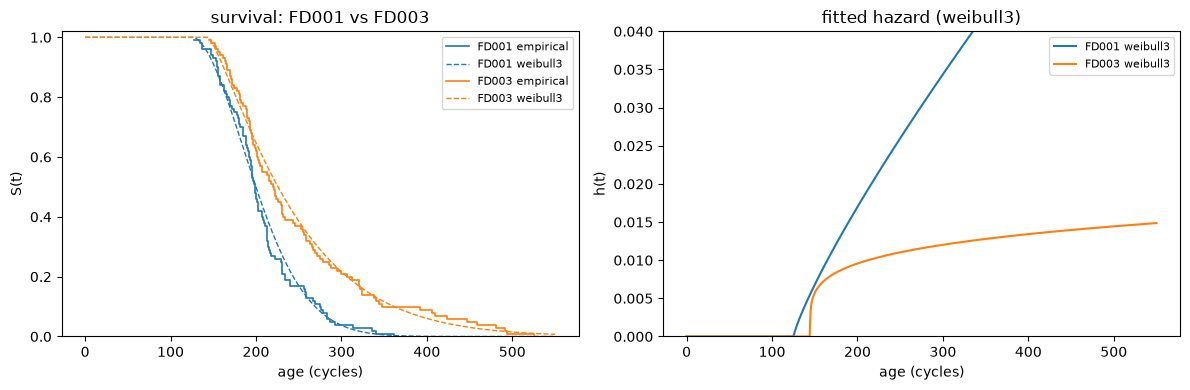

In [12]:
S_emp3 = empirical_survival(life3)
t_grid = np.linspace(0, 550, 551)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for (label, S_e, f), color in zip([("FD001", S_emp, fits), ("FD003", S_emp3, fits3)], ["C0", "C1"], strict=True):
    axes[0].step(S_e.index, S_e.values, where="post", color=color, lw=1.2, label=f"{label} empirical")
    axes[0].plot(t_grid, f["weibull3"].sf(t_grid), color=color, ls="--", lw=1, label=f"{label} weibull3")
    d = f["weibull3"]
    S = d.sf(t_grid)
    axes[1].plot(t_grid, np.where(S > 1e-4, d.pdf(t_grid) / np.maximum(S, 1e-12), np.nan), color=color, label=f"{label} weibull3")
axes[0].set(xlabel="age (cycles)", ylabel="S(t)", title="survival: FD001 vs FD003", ylim=(0, 1.02))
axes[1].set(xlabel="age (cycles)", ylabel="h(t)", title="fitted hazard (weibull3)", ylim=(0, 0.04))
for ax in axes:
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Your reading.** How do shape, scale and tail change between FD001 and FD003? Does the two-parameter Weibull degrade more on FD003 than on FD001, and is that what a mixture should do? Is the FD003 hazard still monotone? What does the longer right tail (max 525 vs 362) imply for the RUL cap of 125 if it were reused on FD003 without re-running notebook 01 section 4?

## 7. Censoring: using the test engines correctly

Every test engine is right-censored: we know it survived at least `age` cycles, not when it failed. Three ways to build a survival curve from train + test:

- Train only: 100 complete lifetimes (what sections 2 to 6 used).
- Naive: count each test engine's cut as if it were a failure.
- Kaplan–Meier: keep censored engines in the at-risk set until their cut, never count them as failures.

The Kaplan–Meier estimator is implemented inline here; if it gets reused it belongs in `src/turbofan_rul/`.

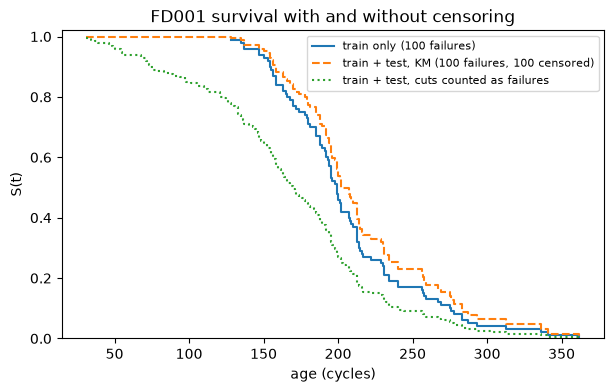

,train only,KM censored,naive
100,1.00,1.000,0.850
150,0.93,0.952,0.645
200,0.46,0.540,0.270
250,0.17,0.229,0.090
300,0.04,0.064,0.025


In [13]:
def kaplan_meier(times, events) -> pd.Series:
    # Product-limit estimator. `events` is 1 for an observed failure, 0 for a censored unit.
    d = pd.DataFrame({"t": np.asarray(times, dtype=float), "e": np.asarray(events, dtype=int)}).sort_values("t")
    survival, out = 1.0, {}
    for t, g in d.groupby("t"):
        at_risk = (d["t"] >= t).sum()
        survival *= 1 - g["e"].sum() / at_risk
        out[t] = survival
    return pd.Series(out, name="S")


km_train = kaplan_meier(life, np.ones(len(life)))
km_naive = kaplan_meier(np.r_[life, test["age"]], np.ones(len(life) + len(test)))
km_censored = kaplan_meier(np.r_[life, test["age"]], np.r_[np.ones(len(life)), np.zeros(len(test))])

fig, ax = plt.subplots(figsize=(7, 4))
for s, label, ls in [(km_train, "train only (100 failures)", "-"), (km_censored, "train + test, KM (100 failures, 100 censored)", "--"), (km_naive, "train + test, cuts counted as failures", ":")]:
    ax.step(s.index, s.values, where="post", label=label, ls=ls)
ax.set(xlabel="age (cycles)", ylabel="S(t)", title="FD001 survival with and without censoring", ylim=(0, 1.02))
ax.legend(fontsize=8)
plt.show()


def s_at(s: pd.Series, t: float) -> float:
    prior = s[s.index <= t]
    return float(prior.iloc[-1]) if len(prior) else 1.0


pd.DataFrame(
    {name: {t: s_at(s, t) for t in [100, 150, 200, 250, 300]} for name, s in [("train only", km_train), ("KM censored", km_censored), ("naive", km_naive)]}
).round(3)

**Your reading.** Which direction does the naive curve err in, and why? Why is the KM curve slightly *above* the train-only curve here? What assumption about *why* engines were censored does KM need, and does the C-MAPSS test file satisfy it? Would a real airline fleet?

---

## Decisions

Fill in after working through the sections.

| # | Question | Decision | Evidence |
|---|----------|----------|----------|
| 1 | Lifetime family for FD001 | | section 3: AIC, quantile table, probability plots |
| 2 | Hazard shape, onset of wear-out | | section 4 |
| 3 | Clock-model baseline (RMSE, PHM08) on FD001 test | | section 5 |
| 4 | Effect of a second fault mode (FD003) | | section 6 |
| 5 | How censored engines enter survival estimates | | section 7 |

Notes to carry into the next notebooks:

- The clock-model scores are the floor for notebook 03 (linear baseline). If a sensor model does not beat them, it is not using the sensors.
- The Weibull3 threshold and the RUL cap of 125 from notebook 01 describe the same fact (no observable degradation in early life) from two sides. State both in one place.
- Age at cut is a legitimate feature for every later model, since it is known for every test engine; the conditional median residual life is a candidate engineered feature.
- `lifetimes`, `test_ages` and `kaplan_meier` are candidates for `src/turbofan_rul/` once notebook 03 needs them.